# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: 84        |         |
| :----------------| :-------|
| Thijn Holswilder | 6536387 |
| Zulfiqar Alwani  |  |

In [36]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
#from IPython import display
from IPython.display import Image, display
from scipy.optimize import curve_fit


epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m)

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

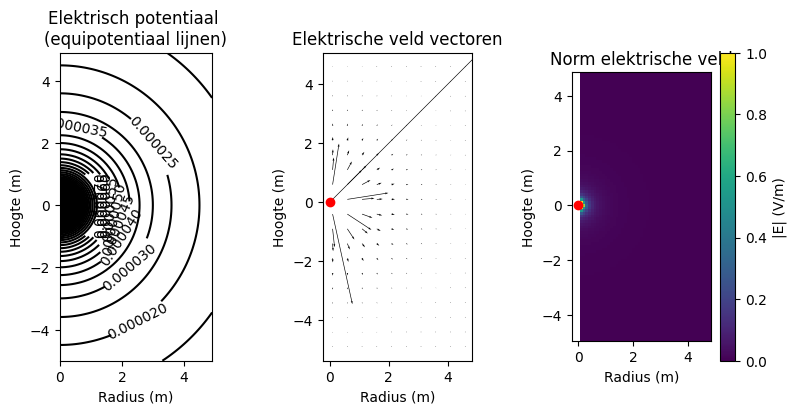

In [37]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print het exponent op een nette manier.

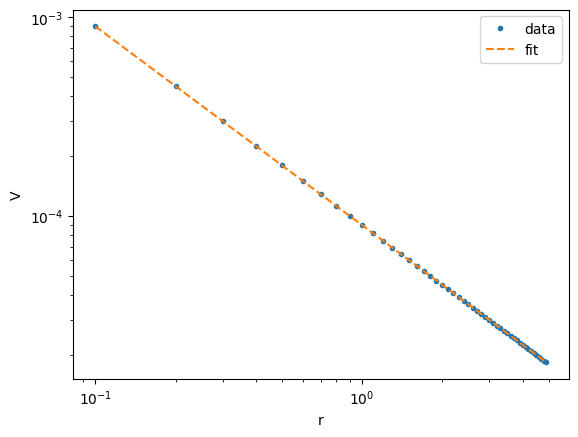

Exponent = -1.0000


In [38]:
# z=0 index bepalen uit z-array
index_z0 = np.argmin(np.abs(z))

# Neem rij bij z=0
V_slice = V[index_z0, :]

# r=0 verwijderen (singulariteit)
r_pos = r[1:]
V_pos = V_slice[1:]

# Model: V = C r^a
def power_law(r, C, a):
    return C * r**a

# Fit
popt, pcov = curve_fit(power_law, r_pos, V_pos)

C_fit, exponent = popt

# Plot
plt.loglog(r_pos, V_pos, '.', label="data")
plt.loglog(r_pos, power_law(r_pos, *popt), '--', label="fit")
plt.xlabel("r")
plt.ylabel("V")
plt.legend()
plt.show()

print(f"Exponent = {exponent:.4f}")


##### Vraag 1b Het elektrische veld rond een puntlading
1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

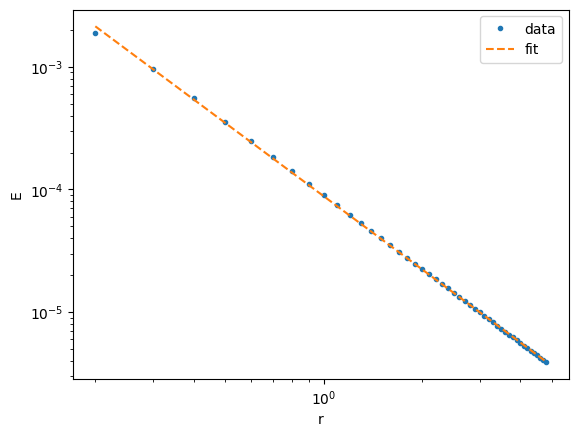

Exponent van E = -1.9806


In [39]:
# neem E bij z=0
E_slice = normE[index_z0, :]

# verwijder r=0
r_pos = r_for_E[1:]
E_pos = E_slice[1:]

# log-log waarden
log_r = np.log(r_pos)
log_E = np.log(E_pos)

# lineaire fit
a, b = np.polyfit(log_r, log_E, 1)

# plot
plt.loglog(r_pos, E_pos, '.', label="data")
plt.loglog(r_pos, np.exp(b) * r_pos**a, '--', label="fit")
plt.xlabel("r")
plt.ylabel("E")
plt.legend()
plt.show()

print(f"Exponent van E = {a:.4f}")

### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [40]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius = 3  # (m)
grid_step = 0.1  # (m)
z_coord_DISK = 0 # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

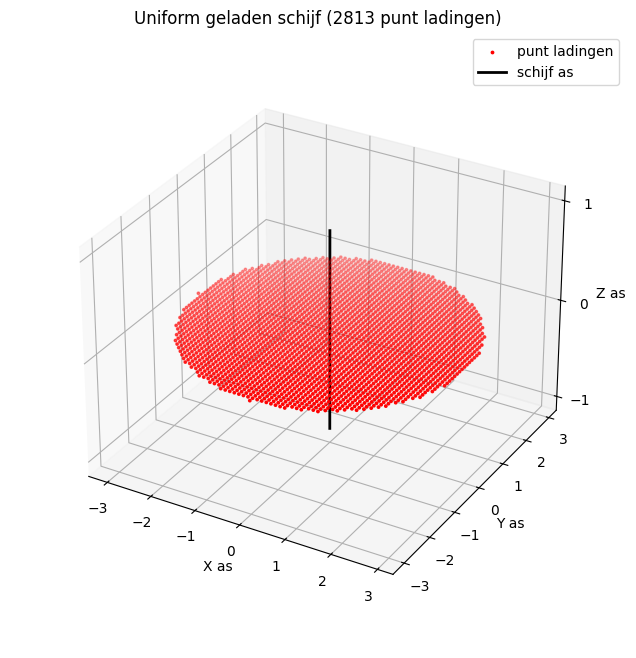

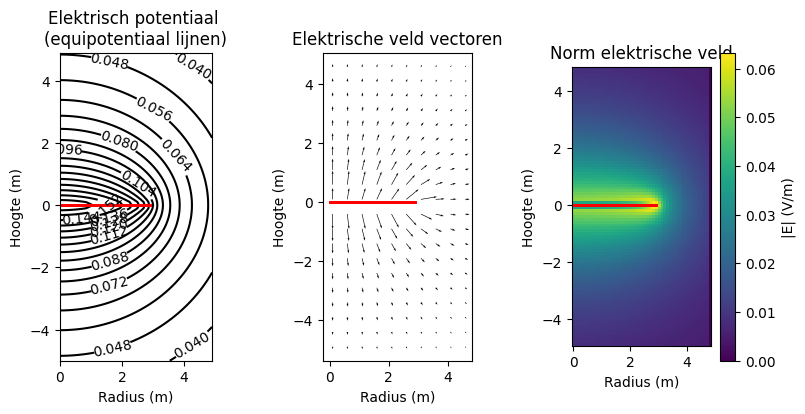

In [41]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat?
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie?
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a

1. **Disk radius**

De disk radius is de straal van de schijf.  
Als deze naar nul gaat blijft er één puntlading over en gedraagt het systeem zich als een puntlading.

2. **Grid step**

De grid step is de afstand tussen roosterpunten.  
Een kleinere grid step zorgt voor meer roosterpunten en dus meer puntladingen, wat de simulatie nauwkeuriger maar trager maakt.

3. **Inter charge distance**

De inter charge distance bepaalt hoe dicht de puntladingen op de schijf bij elkaar liggen.  
Een kleinere afstand betekent meer puntladingen en een betere benadering, maar ook meer rekentijd.

#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [42]:
import numpy as np

# Totale lading op de schijf
Q = number_point_charges_on_disk * charge_one_point

# Oppervlakte van de schijf
A = np.pi * disk_radius**2

# Ladingsdichtheid
sigma = Q / A

print(f"Ladingsdichtheid sigma = {sigma:.3e} C/m^2")

Ladingsdichtheid sigma = 9.949e-13 C/m^2


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

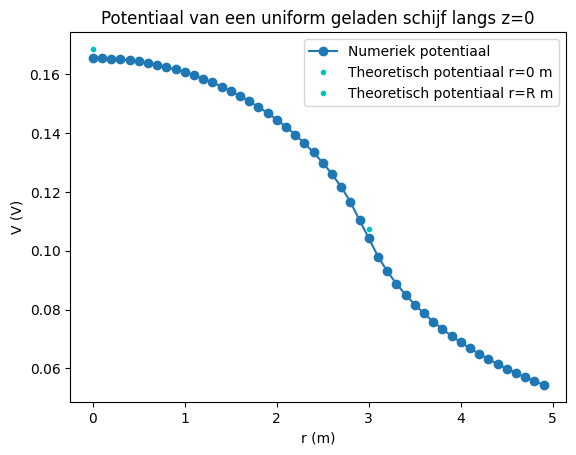

In [43]:
# index van z = 0
idx_z_zero = np.argmin(np.abs(z))

# numeriek potentiaal langs r-as (z=0)
V_r = V[idx_z_zero, :]

# theoretische waarden
V_0 = sigma * disk_radius / (2 * epsilon0)      # potentiaal in centrum
V_R = sigma * disk_radius / (np.pi * epsilon0)  # potentiaal op rand
r_R = disk_radius

plt.title("Potentiaal van een uniform geladen schijf langs z=0")
plt.plot(r, V_r, "o-", label="Numeriek potentiaal")
plt.plot(0, V_0, "c.", label="Theoretisch potentiaal r=0 m")
plt.plot(r_R, V_R, "c.", label="Theoretisch potentiaal r=R m")
plt.legend()
plt.xlabel("r (m)")
plt.ylabel("V (V)")
plt.show()



#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.


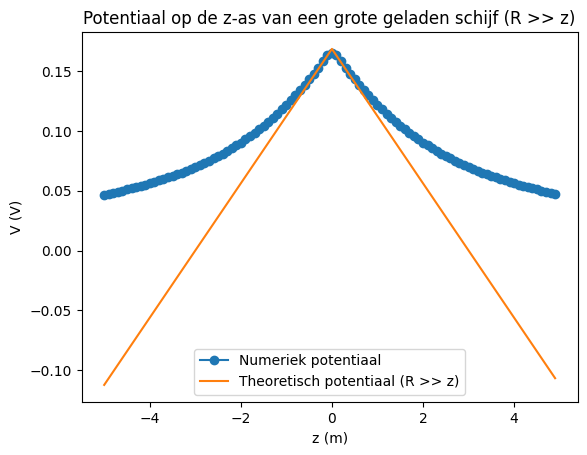

In [44]:
# index van r = 0
idx_r_zero = np.argmin(np.abs(r))

# numeriek potentiaal op de z-as
V_z = V[:, idx_r_zero]

# theoretisch potentiaal (R >> z benadering)
V_theory = (sigma / (2 * epsilon0)) * (disk_radius - np.abs(z))

plt.figure()
plt.title("Potentiaal op de z-as van een grote geladen schijf (R >> z)")
plt.plot(z, V_z, "o-", label="Numeriek potentiaal")
plt.plot(z, V_theory, "-", label="Theoretisch potentiaal (R >> z)")
plt.xlabel("z (m)")
plt.ylabel("V (V)")
plt.legend()

plt.savefig("vraag_2d_potentiaal_z_as.png")
plt.show()

#### Vraag 2e

Het theoretische elektrische veld van een oneindig geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig geladen oppervlak.
3. Sla deze plot ook op.

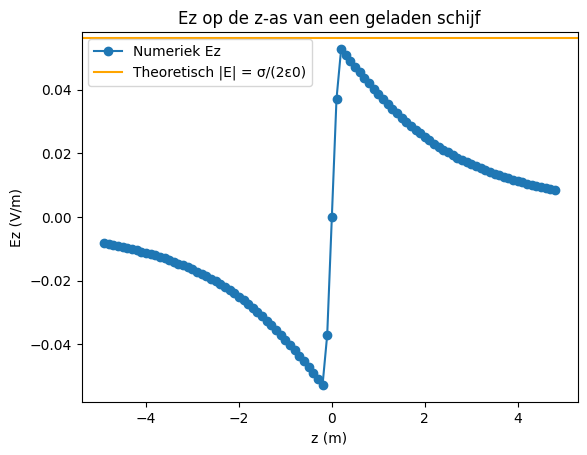

In [45]:
# index van r = 0 in verkorte r-array
idx_r_zero = np.argmin(np.abs(r_for_E))

# numeriek Ez op de z-as
Ez_z = Ez[:, idx_r_zero]

# theoretisch veld voor oneindig oppervlak
E_theory = sigma / (2 * epsilon0)

plt.figure()
plt.title("Ez op de z-as van een geladen schijf")
plt.plot(z_for_E, Ez_z, "o-", label="Numeriek Ez")
plt.axhline(E_theory, color="orange", label="Theoretisch |E| = σ/(2ε0)")

plt.xlabel("z (m)")
plt.ylabel("Ez (V/m)")
plt.legend()

plt.savefig("vraag_2e_Ez_z_as.png")
plt.show()

#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?
2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

##### Antwoorden 2f

1.  Het elektrische veld van de schijf benadert dat van een oneindige plaat in het midden van de schijf, dicht bij z = 0 en zolang de afstand tot de rand klein is. In dat gebied is het veld vrijwel constant.

2.  In de grafiek zie je twee sprongen bij ongeveer z ≈ ±1. Deze ontstaan doordat het elektrische veld van richting verandert wanneer je door het geladen schijfvlak gaat; bij een oppervlaktelading maakt het veld een sprong.
Tussen deze sprongen is het veld ongeveer constant, wat het gedrag van een (bijna) oneindige plaat benadert. Verder van de schijf neemt het veld af, omdat de schijf eindig is en rand-effecten optreden.

#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

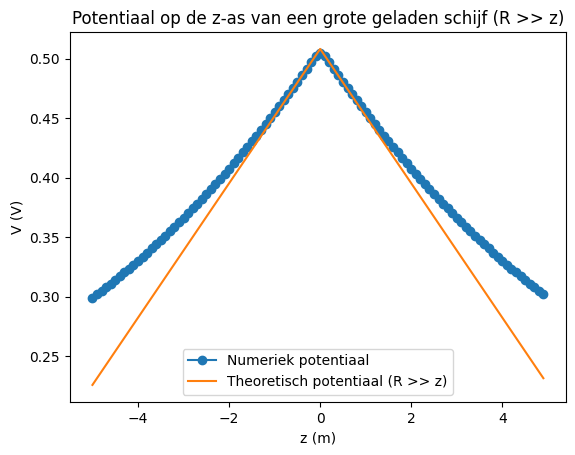

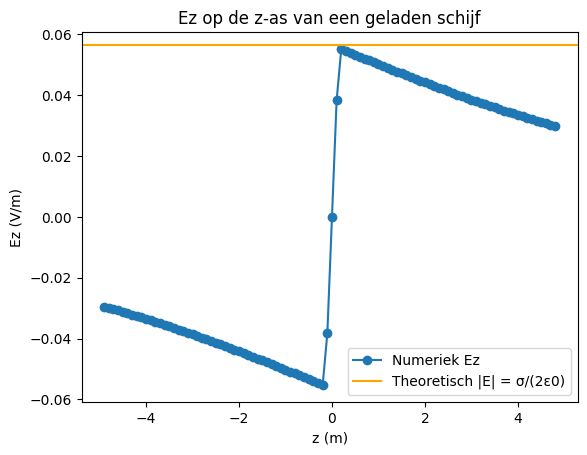

In [46]:
###
###Jouw code hier###
###
display(Image("2d_radius=9.png"))
display(Image("2e_radius=9.png"))


##### Antwoorden 2g

Bij een grotere straal (R = 9 m) benadert het potentiaal en het elektrische veld duidelijk beter dat van een oneindige plaat. Het potentiaal langs de z-as wordt lineairder rond het midden en het elektrische veld blijft over een groter gebied bijna constant.

Bij de kleinere straal (R = 3 m) treden rand-effecten sneller op: het veld begint dichter bij het centrum al af te nemen en wijkt sneller af van de theoretische constante waarde. Dit komt doordat bij een grotere schijf het midden verder van de rand ligt, waardoor het systeem zich lokaal meer gedraagt als een oneindig oppervlak.

#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

##### Antwoord 2h

Het veld van een oneindige plaat is constant en gelijk aan σ/(2ε₀).  
We stellen het veld van de schijf gelijk aan 10% van deze waarde en lossen de vergelijking analytisch op naar z.

Uit de vergelijking volgt dat z ongeveer 2,06 keer de straal R moet zijn.  
Dat betekent dat het veld pas sterk afneemt (tot 10% van de oneindige plaat) wanneer je ongeveer twee keer de schijfstraal boven het midden zit.

### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

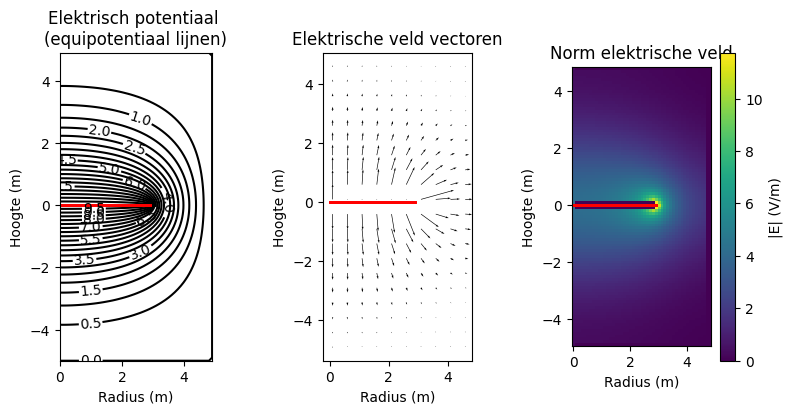

In [47]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)

# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)

"""--------------------------------------------------------------------
Veldberekening voor een geleidende schijf
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veld sterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

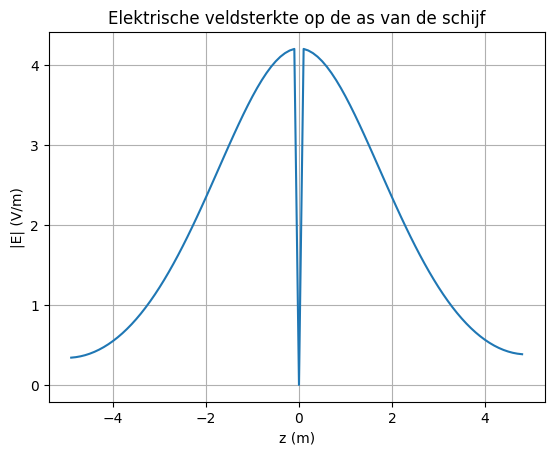

 Elektrisch veld op de as dichtbij het midden
 z-positie is -1.7764e-14 m
 |E| is 1.5214e-05 V/m


In [48]:
###
Er, Ez, normE = compute_E_disk(V,B,grid_step)

# Elektrisch veld op de as bij r=0


E_axis = normE[:, 0]     # eerste kolom r = 0
z_axis = z_for_E         

plt.figure()
plt.plot(z_axis, E_axis)
plt.xlabel("z (m)")
plt.ylabel("|E| (V/m)")
plt.title("Elektrische veldsterkte op de as van de schijf")
plt.grid()
plt.show()

#Veld dichtbij het midden


idx_middle = np.argmin(np.abs(z_axis))   # index waar z ≈ 0
E_middle = E_axis[idx_middle]

print(" Elektrisch veld op de as dichtbij het midden")

print(f" z-positie is {z_axis[idx_middle]:.4e} m")
print(f" |E| is {E_middle:.4e} V/m")


#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)?
2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

##### Antwoord 3b

*Geef in deze markdown cel je antwoord op 3b.1.*

In [49]:
#### Print met deze cel met een nette opmaak je antwoord op vraag 3b 2.

#Bij r=0 en z=0 geldt voor de oppervlaktelading in het midden van de schijf \sigma= e_0 * Eloodrecht

# Oppervlaktelading in het midden

epsilon0 = 8.854e-12  # F/m

# index van r = 0
r_index = 0

# index net boven z = 0
z_index = np.argmin(np.abs(z_for_E)) + 1

Ez_surface = Ez[z_index, r_index]


#voorwaarde aan het oppervlak (vanuit griffiths boek) is Ebuiten-Ebinnen= \sigma/e_0
#Ebinnen= 0, dus volgt hieronder:
sigma_middle = epsilon0 * Ez_surface

print(" Oppervlakteladingsdichtheid in het midden")

print(f" z-positie gebruikt {z_for_E[z_index]:.4e} m")
print(f" Ez net buiten {Ez_surface:.4e} V/m")
print(f" sigma(0) {sigma_middle:.4e} C/m^2")


 Oppervlakteladingsdichtheid in het midden
 z-positie gebruikt 1.0000e-01 m
 Ez net buiten 4.2018e+00 V/m
 sigma(0) 3.7203e-11 C/m^2


#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


 Totale lading op de schijf
 Q = 2.104e-09 C
 Vergelijking ladingsdichtheid in het centrum
 sigma_geleidend(0) = 3.7203e-11 C/m^2
 sigma_uniform  = 7.4406e-11 C/m^2


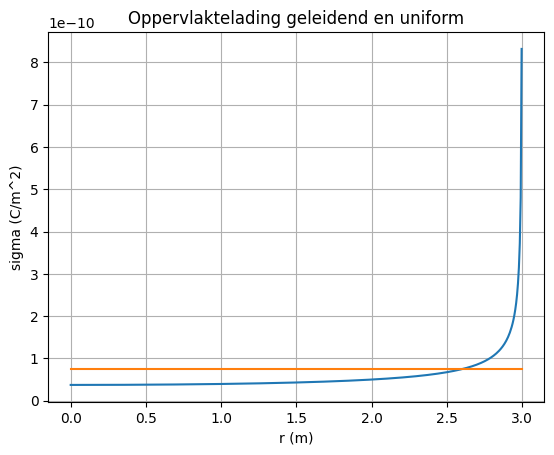

In [50]:

# 1) Totale lading Q berekenen

#voor geleidende schijf geldt \sigma= Q/(2pi*r^2) , hieruit volgt hieronder formule voor Q

R = disk_radius

Q = 2 * np.pi * R**2 * sigma_middle

print(" Totale lading op de schijf")
print(f" Q = {Q:.3e} C")

# 2) vergelijk oppervlakte lading in centrum vd geleidende schijf met dat van uniform geladen schijf

sigma_uniform = Q / (np.pi * R**2)

print(" Vergelijking ladingsdichtheid in het centrum")
print(f" sigma_geleidend(0) = {sigma_middle:.4e} C/m^2")
print(f" sigma_uniform  = {sigma_uniform:.4e} C/m^2")

# 3) sigma(r) voor geleidende schijf

r_values = np.linspace(0, R*0.999, 500)

sigma_conducting = Q / (2 * np.pi * R * np.sqrt(R**2 - r_values**2))

# 4) uniforme schijf
sigma_uniform_array = np.ones_like(r_values) * sigma_uniform

plt.figure()
plt.plot(r_values, sigma_conducting)
plt.plot(r_values, sigma_uniform_array)

plt.xlabel("r (m)")
plt.ylabel("sigma (C/m^2)")
plt.title("Oppervlaktelading geleidend en uniform")
plt.grid()
plt.show()



#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [51]:
# Deze cel kan je gebruiken om van vraag 3c 1 tot en met 4 te beantwoorden.

# 1) maximum elektrisch veld

E_max = np.max(normE)

# index van maximum
idx_max = np.unravel_index(np.argmax(normE), normE.shape)

z_max = z_for_E[idx_max[0]]
r_max = r_for_E[idx_max[1]]

# 2) elektrisch veld in het midden

idx_middle = np.argmin(np.abs(z_for_E))
E_middle = normE[idx_middle, 0]

#3) hoevel hoger
ratio= E_max / E_middle

#4) nette geprinte waardes met opmaak

print("=================================================")
print(f" Maximum |E|              : {E_max:.4e} V/m")
print(f" Locatie maximum (r,z)    : ({r_max:.4e}, {z_max:.4e}) m")
print("-------------------------------------------------")
print(f" |E| in het midden        : {E_middle:.4e} V/m")
print(f" Versterkingsfactor       : {ratio:.2f} keer groter")
print("=================================================")




 Maximum |E|              : 1.1753e+01 V/m
 Locatie maximum (r,z)    : (3.0000e+00, 1.0000e-01) m
-------------------------------------------------
 |E| in het midden        : 1.5214e-05 V/m
 Versterkingsfactor       : 772488.59 keer groter


##### Antwoord 3d.5

Het hoge veld komt doordat aan de rand de kromming groter is, hierdoor concentreren daar de veldlijnen. 

Daarnaast, zie formule van 3c: $$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

Als r--> R gaat, dan gaat $$\sigma(r)$$  naar oneindig

### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

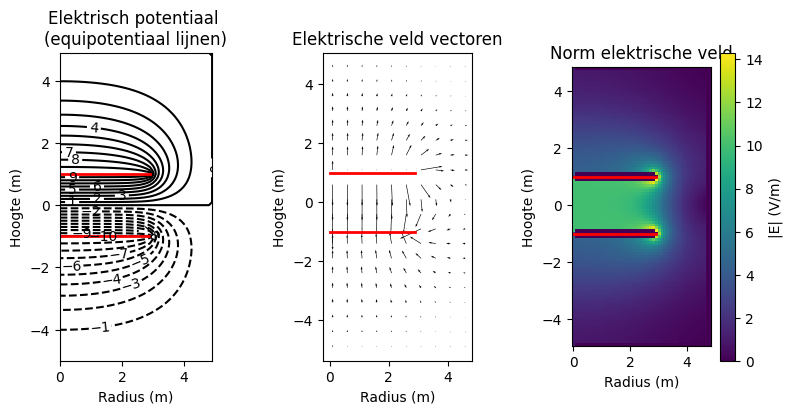

In [52]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 2  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)


#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


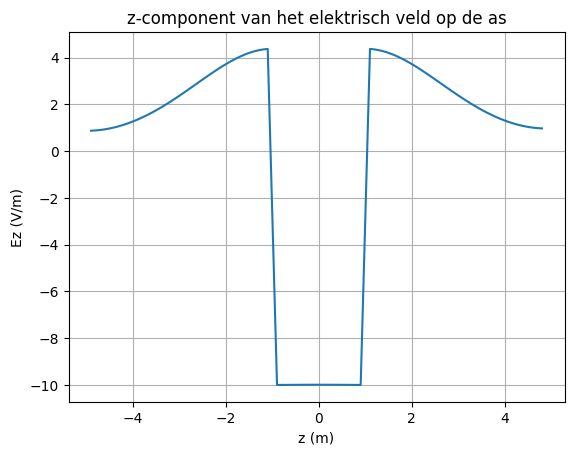

In [53]:
###
###your code here###
# Ez-component op de as (r = 0)

Ez_axis = Ez[:, 0]      # eerste kolom = r = 0
z_axis = z_for_E        # bijhorende z-coördinaten

plt.figure()
plt.plot(z_axis, Ez_axis)

plt.xlabel("z (m)")
plt.ylabel("Ez (V/m)")
plt.title("z-component van het elektrisch veld op de as")
plt.grid()
plt.show()


#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ and $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

##### Antwoorden 4b

*Laat in deze markdown cel je antwoorden op vraag 4b zien.*

1. Bij de onderste plaat is de potentiaal, V=0
Bij de bovenste plaat is V=V1
De afstand tussen de platen is d
Tussen de platen is het potentiaal $$V(z)= V_1/d *z$$ 
Het elektrisch veld in de z-richting is de afgeleide in de z-richting *-1
Dus $$E_z= -V_1/d$$

![image.png](attachment:image.png)

2. Dit is te zien in de plot en is logisch want tussen de platen is er ongeveer een constant veld en buiten de platen gaat het veld naar 0 toe. In het midden bj r=0 komt dus het theoretische uniforme veld zeer goed overeen met het uniforme veld. Maar dicht bij de rand is er een afwijking gezien.
3. Bij 2 platen is het veld tussen de platen bijna uniform, het veld groter en stabieler in het midden.
Bij een enkele plaat is het veld niet-uniform, sterker 'edge effect' en kleiner veld in het midden. 


#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

In [54]:
epsilon0 = 8.854e-12

# Potentiaalverschil
delta_V = V1 - V0

# Afstand tussen platen
d = np.abs(z_pos_disk2 - z_pos_disk1)

R = disk_radius

A = np.pi * R**2

# 1️) Oppervlaktelading binnenzijde
sigma_inside = epsilon0 * delta_V / d

# 2) Totale lading per plaat
Q_plate = sigma_inside * A

# 3️) Capaciteit
C = Q_plate / delta_V

#4) netjes printe


print(f" Plaatafstand d : {d:.2e} m")
print(f" Oppervlakte A  : {A:.2e} m^2")
print("------------------------------------------")
print(f" Oppervlaktelading sigma : {sigma_inside:.2e} C/m^2")
print(f" Totale lading per plaat Q : {Q_plate:.2e} C")
print("------------------------------------------")
print(f" Capaciteit C : {C:.2e} F")

 Plaatafstand d : 2.00e+00 m
 Oppervlakte A  : 2.83e+01 m^2
------------------------------------------
 Oppervlaktelading sigma : 4.43e-11 C/m^2
 Totale lading per plaat Q : 1.25e-09 C
------------------------------------------
 Capaciteit C : 1.25e-10 F


#### Vraag 4d: Theoretische oppervlakte lading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

##### Antwoorden 4d

1. De lading aan de binnenkant is inderdaad nul, want de veldlijnen lopen alleen tussen de platen. Dus het elektrisch veld buiten de plaat is 0. $$\sigma= \epsilon_o * E_lloodrecht$$ Maar buiten de platen is $$E_lloodrecht=0$$ Dus buiten de platen is $$\sigma=0$$

Binnenin de geleider is het elektrisch veld nul.
Het elektrisch veld nabij het oppervlak van een geleider is $$Ebuiten-Ebinnen= \sigma/\epsilon_o$$
Aangezien $$Ebinnen=0 $$  volgt voor het elektrisch veld nabij het oppervlak $$Ebuiten= \sigma/\epsilon_o$$

#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [55]:
#2) ladingsdichtheid=sigma= epsilon_nul * E_buiten

# ladingsdichtheid onderste plaat numeriek

epsilon0 = 8.854e-12


r_index = 0

# index van z-positie onderste plaat
z_plate_index = np.argmin(np.abs(z_for_E - z_pos_disk1))

# net onder de plaat
Ez_onder = Ez[z_plate_index - 1, r_index]

# net boven de plaat
Ez_boven = Ez[z_plate_index + 1, r_index]


# Onderzijde (normaalvector n_dakje wijst naar -z)
sigma_onder = epsilon0 * (-Ez_onder)

# Bovenzijde (normaal wijst naar +z)
sigma_boven = epsilon0 * Ez_boven

print(f" Ez net onder plaat      : {Ez_onder:.2e} V/m")
print(f" sigma onderzijde        : {sigma_onder:.3e} C/m^2")
print("-------------------------------------------------")
print(f" Ez net boven plaat      : {Ez_boven:.2e} V/m")
print(f" sigma bovenzijde        : {sigma_boven:.3e} C/m^2")


 Ez net onder plaat      : -1.00e+01 V/m
 sigma onderzijde        : 8.858e-11 C/m^2
-------------------------------------------------
 Ez net boven plaat      : 4.38e+00 V/m
 sigma bovenzijde        : 3.876e-11 C/m^2


#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

##### Antwoorden 4f

Uit vraag 4d en 4e is te concluderen dat de doodwerkelijke lading op een schrijf is $$Qwerkelijk= Qbinnen + Qbuiten$$ Dus Qwerkelijk is iets groter dan Qtheoretisch berekent bij 4c, want de kleine lading op de buitenkant wordt meegenomen. De capaciteit is C=Q/delta_V, dus de werkelijke capaciteit is groter dan die bij 4c. Als de afstand kleiner wordt, stijgt de capaciteit want $$C= \epsilon_o*A/d$$

### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname).
2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is.
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

In [56]:
def vlakkeplaat(A, d, epsilon_r=1):
    # A = oppervlakte (m^2)
    # d = afstand tussen platen (m)
    # epsilon_r = relatieve permittiviteit
    epsilon0 = 8.854e-12
    epsilon = epsilon0 * epsilon_r
    C = epsilon * A / d
    return C


def cilinder(a, b, L, epsilon_r=1):
    # a = binnenstraal (m)
    # b = buitenstraal (m)
    # L = lengte (m)
    epsilon0 = 8.854e-12
    epsilon = epsilon0 * epsilon_r
    C = 2 * np.pi * epsilon * L / np.log(b/a)
    return C

#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


In [57]:
# Gegeven waarden
A = 0.10 * 0.10          # 10 cm x 10 cm -> m^2
d = 1e-3                 # 1 mm -> m

a = 9e-3 / 2             # binnendiameter 9 mm -> straal
b = 10e-3 / 2            # buitendiameter 10 mm -> straal
L = 0.10                 # 10 cm -> m

# relatieve permittiviteiten
epsilon_r_lucht = 1
epsilon_r_water = 80
epsilon_r_pvc = 3

# 1 lucht
C_plaat_lucht = vlakkeplaat(A, d, epsilon_r_lucht)
C_cil_lucht = cilinder(a, b, L, epsilon_r_lucht)

# 3 afstand verdubbeld
C_plaat_dubbel = vlakkeplaat(A, 2*d, epsilon_r_lucht)
C_cil_dubbel = cilinder(a, a + 2*(b-a), L, epsilon_r_lucht)

# 4 water
C_plaat_water = vlakkeplaat(A, d, epsilon_r_water)
C_cil_water = cilinder(a, b, L, epsilon_r_water)

# 5 PVC
C_plaat_pvc = vlakkeplaat(A, d, epsilon_r_pvc)
C_cil_pvc = cilinder(a, b, L, epsilon_r_pvc)

print("=== Lucht ===")
print(f"Vlakke plaat: {C_plaat_lucht:.3e} F")
print(f"Cilinder:     {C_cil_lucht:.3e} F")

print("\n=== Afstand verdubbeld (lucht) ===")
print(f"Vlakke plaat: {C_plaat_dubbel:.3e} F")
print(f"Cilinder:     {C_cil_dubbel:.3e} F")

print("\n=== Water ===")
print(f"Vlakke plaat: {C_plaat_water:.3e} F")
print(f"Cilinder:     {C_cil_water:.3e} F")

print("\n=== PVC ===")
print(f"Vlakke plaat: {C_plaat_pvc:.3e} F")
print(f"Cilinder:     {C_cil_pvc:.3e} F")

=== Lucht ===
Vlakke plaat: 8.854e-11 F
Cilinder:     5.280e-11 F

=== Afstand verdubbeld (lucht) ===
Vlakke plaat: 4.427e-11 F
Cilinder:     2.772e-11 F

=== Water ===
Vlakke plaat: 7.083e-09 F
Cilinder:     4.224e-09 F

=== PVC ===
Vlakke plaat: 2.656e-10 F
Cilinder:     1.584e-10 F


#### Vraag 5c: Condensatoren uit het dagelijkse leven

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
1. In figuur 5.1 is een condensator te zien van 1 $\micro$F, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.
Stel dat we een vierkante plaat condensator hebben van 1 $\micro$F.
2. Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

In [58]:
C = 1e-6  # 1 microF

# 1 Cilinder
a = 2.5e-3
b = 3.0e-3

L = C * np.log(b/a) / (2 * np.pi * epsilon0)

# 2 Vlakke plaat
d = 0.5e-3
breedte = 6e-3

lengte_plaat = C * d / (epsilon0 * breedte)

print("=== 1 microF benaderingen ===")
print(f"Benodigde lengte cilinder: {L:.3f} m")
print(f"Benodigde lengte vlakke plaat: {lengte_plaat:.3f} m")

=== 1 microF benaderingen ===
Benodigde lengte cilinder: 3277.318 m
Benodigde lengte vlakke plaat: 9411.942 m


#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.

##### Antwoorden 5d

1.  De berekende lengtes van enkele kilometers zijn niet realistisch. Een condensator van 1 µF past in werkelijkheid in een paar centimeter. Dit laat zien dat een luchtcondensator met deze afmetingen nooit zo’n hoge capaciteit kan hebben.

2.  Uit de formule \( C = \varepsilon A / d \) volgt dat je de capaciteit vergroot door:
- een veel grotere effectieve oppervlakte \( A \),
- een veel kleinere plaatafstand \( d \),
- en een veel grotere permittiviteit \( \varepsilon \).

    In echte condensatoren gebruiken ze daarom:
- opgerolde folies (grote effectieve oppervlakte),
- een extreem dun diëlektricum,
- en materialen met hoge \( \varepsilon_r \) (bijvoorbeeld elektrolyt).

#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


In [59]:
# Gegeven
v_kmh = 70
v = v_kmh / 3.6          # m/s
V = 10e3                 # 10 kV
epsilon_r_water = 80
d = 1e-3                 # 1 mm

# 1 schatting massa
massa = 6 * 80 + 200     # 6 personen (~80 kg) + trein (~200 kg)

# 2 kinetische energie
E = 0.5 * massa * v**2

# 3 benodigde capaciteit
C = 2 * E / V**2

# 4 oppervlakte vlakke plaat condensator (water)
epsilon = epsilon0 * epsilon_r_water
A = C * d / epsilon

print("=== Achtbaan condensator berekening ===")
print(f"Schatting massa treintje: {massa:.1f} kg")
print(f"Eind snelheid: {v:.2f} m/s")
print(f"Benodigde energie: {E:.2f} J")
print(f"Benodigde capaciteit: {C:.6f} F")
print(f"Benodigd oppervlak (water, d=1 mm): {A:.2f} m^2")

=== Achtbaan condensator berekening ===
Schatting massa treintje: 680.0 kg
Eind snelheid: 19.44 m/s
Benodigde energie: 128549.38 J
Benodigde capaciteit: 0.002571 F
Benodigd oppervlak (water, d=1 mm): 3629.70 m^2


##### Antwoorden 5e

Nee, dit is niet realistisch als vlakke plaat condensator. Zelfs met water als diëlektricum is er een oppervlak van tientallen vierkante meters nodig, wat praktisch niet haalbaar is in een compacte installatie.

In de praktijk lossen ze dit op door gebruik te maken van supercondensatoren met extreem groot intern oppervlak (opgerolde of poreuze structuren), zeer dunne diëlektrica en materialen met hoge permittiviteit. Daardoor kan dezelfde energie in een veel kleiner volume worden opgeslagen.

#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

=== Vlakke plaat condensator ===
C bij 0.5 mm: 1.771e-10 F
C bij 5 mm:   1.771e-11 F


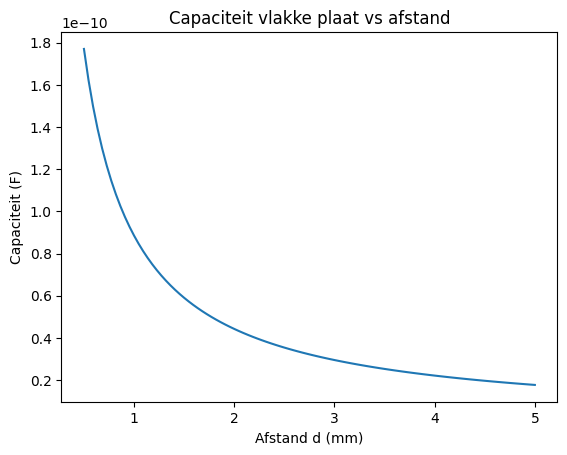


=== Cilindercondensator ===
C bij volledige overlap (10 cm): 5.280e-11 F
C bij volledig uitgetrokken:     0.000e+00 F


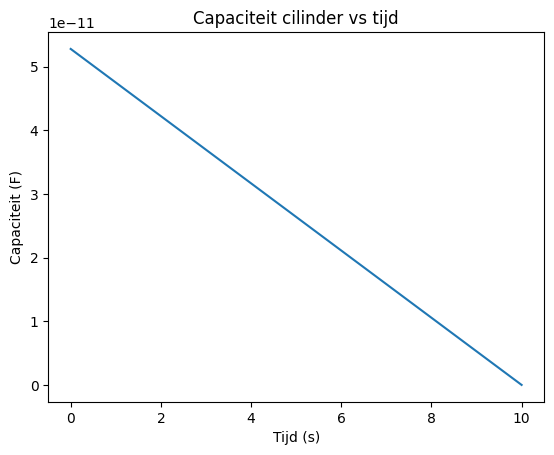

In [60]:
# ===== 1 Vlakke plaat =====
A = 0.10 * 0.10  # 10 cm x 10 cm

d_start = 0.5e-3
d_end = 5e-3

C_start = vlakkeplaat(A, d_start)
C_end = vlakkeplaat(A, d_end)

print("=== Vlakke plaat condensator ===")
print(f"C bij 0.5 mm: {C_start:.3e} F")
print(f"C bij 5 mm:   {C_end:.3e} F")


# plot
d_values = np.linspace(d_start, d_end, 100)
C_plaat = vlakkeplaat(A, d_values)

plt.figure()
plt.plot(d_values * 1e3, C_plaat)
plt.xlabel("Afstand d (mm)")
plt.ylabel("Capaciteit (F)")
plt.title("Capaciteit vlakke plaat vs afstand")
plt.show()


# ===== 2 Cilinder =====
a = 9e-3 / 2
b = 10e-3 / 2
L_max = 0.10  # 10 cm

C_begin = cilinder(a, b, L_max)
C_eind = cilinder(a, b, 0.0)

print("\n=== Cilindercondensator ===")
print(f"C bij volledige overlap (10 cm): {C_begin:.3e} F")
print(f"C bij volledig uitgetrokken:     {C_eind:.3e} F")


# plot
t = np.linspace(0, 10, 100)
L_values = L_max * (1 - t/10)
C_cil = cilinder(a, b, L_values)

plt.figure()
plt.plot(t, C_cil)
plt.xlabel("Tijd (s)")
plt.ylabel("Capaciteit (F)")
plt.title("Capaciteit cilinder vs tijd")
plt.show()

## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6) Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

Verander de tekst hieronder zodat deze naar jouw foto verwijst. Zorg dat de foto in de map figures staat!
![figure 5.1](figures/Condensator_1_uF.jpg)

#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.


##### Antwoorden 6a

$$
\begin{array}{c}

\text{Bovenplaat} \\
\hline
\varepsilon_{r1} \text{ (karton)},\; d_1 \\
\hline
\varepsilon_{r2} \text{ (ducttape)},\; d_2 \\
\hline
\text{Onderplaat}

\end{array}
$$

Totale capaciteit (serie diëlektrica):

$$
\frac{1}{C} =
\frac{d_1}{\varepsilon_0 \varepsilon_{r1} A}
+
\frac{d_2}{\varepsilon_0 \varepsilon_{r2} A}
$$

$$
C =
\frac{\varepsilon_0 A}
{\dfrac{d_1}{\varepsilon_{r1}} + \dfrac{d_2}{\varepsilon_{r2}}}
$$

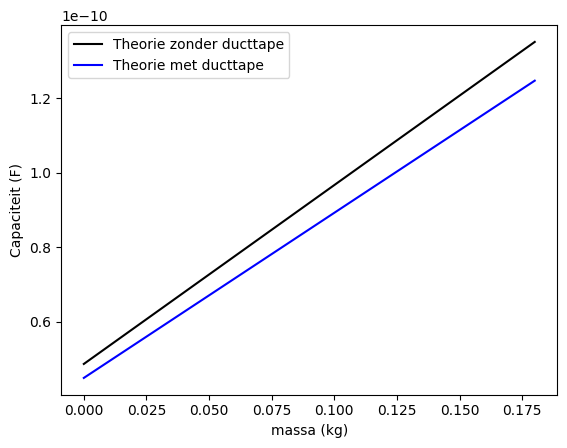

In [61]:
epsilon_0 = 8.854187817e-12

d1 = 0.001            # karton
d2 = 0.0001           # ducttape (0.1 mm)

epsilon_r_carton = 2.5
epsilon_r_ductape = 3.0

w = 0.1

m = np.array([0,180]) * 1e-3
x = np.array([2.2,6.1]) * 1e-2

A = x * w

# oude theorie (zonder ducttape)
C_oud = epsilon_0 * epsilon_r_carton * A / d1

# nieuwe theorie (met ducttape in serie)
C_nieuw = epsilon_0 * A / (d1/epsilon_r_carton + d2/epsilon_r_ductape)

plt.figure()
plt.plot(m, C_oud, "k-", label="Theorie zonder ducttape")
plt.plot(m, C_nieuw, "b-", label="Theorie met ducttape")
plt.xlabel("massa (kg)")
plt.ylabel("Capaciteit (F)")
plt.legend()
plt.show()

##### Antwoorden 6a

De blauwe lijn (met ducttape) ligt systematisch onder de zwarte lijn (zonder ducttape). Dit komt doordat de extra laag ducttape effectief extra dikte toevoegt aan het diëlektricum. Omdat de capaciteit omgekeerd evenredig is met de effectieve dikte, wordt de capaciteit kleiner wanneer deze extra laag wordt meegerekend.

Daardoor is ook de helling van de kalibratielijn kleiner: bij toenemende massa (groter overlapoppervlak) groeit de capaciteit minder sterk dan in het oorspronkelijke model. 

Het verschil tussen de twee lijnen laat zien dat het negeren van een dun extra diëlektricum leidt tot een systematische overschatting van de capaciteit in het theoretische model.

#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf(disk) condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1

*Vergelijk hier de factoren tussen de circulaire en vierkante vlakke plaat condensatoren.*

#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk dit met de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

In [62]:
# Schrijf hier jouw code die de vlakke plaat capaciteit omschrijft naar de werkelijke capaciteit

# def C_niet_ideaal(#relevante parameters):
    # Jouw berekeningen


##### Antwoorden 6b2

*Doe in deze markdown cel je vergelijkingen voor de sanity check condensator en je kalibratiegrafiek.*

#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons|  |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.
2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

##### Antwoorden 6c 1

*Antwoord vraag 6c 1.*

#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

In [63]:
 # Pas deze code aan zodat jouw opstelling doorgerekend wordt
def E_condensator(x1, x2, D):
    return None

#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

##### Antwoorden 7

Een deel van de afwijking tussen de metingen en de oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door de extra laag ducttape. Door deze dunne laag wordt de effectieve afstand tussen de platen groter, waardoor de capaciteit systematisch lager uitvalt dan in het oorspronkelijke model werd voorspeld. Dit verklaart een constante verschuiving naar beneden en een iets kleinere helling van de kalibratielijn.

De rest van de afwijking kan worden verklaard door niet-ideale effecten in de opstelling. Kleine variaties in de plaatafstand bij het verschuiven van de plaat hebben een groot effect op de capaciteit, Omdat $C = \frac{\varepsilon A}{d}$ geldt $C \propto \frac{1}{d}$. Ook randvelden (het veld is in werkelijkheid niet perfect uniform), imperfecte uitlijning van de platen en het niet-ideale gedrag van de veer kunnen bijdragen aan afwijkingen. 

De grafieken laten zien dat het verband lineair blijft, maar met een verschuiving in de y-richting. Dit wijst op een systematische fout (bijvoorbeeld een verkeerd nulpunt of extra effectieve dikte), terwijl de lineariteit bevestigt dat het onderliggende fysische model in de basis klopt.